In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import *

## Semi-Analytical Solution for zero relaxation

In [2]:
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

In [3]:
rho_L, v_L, theta_L = 7.0, 0.0, 1.0
rho_R, v_R, theta_R = 1.0, 0.0, 1.0

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

In [4]:
x = np.linspace(-6, 6, 10_000)
c = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, x, c[:, None], T)
rho_T = np.trapz(f_T, c, axis=0)
v_T = np.trapz(c[:, None] * f_T, c, axis=0) / rho_T
theta_T = np.trapz((c[:, None] - v_T)**2 * f_T, c, axis=0) / rho_T
p_T = rho_T * theta_T
u4 = np.trapz(c[:,None]**3 * f_T, c, axis=0)
u5 = np.trapz(c[:,None]**4 * f_T, c, axis=0)

/tmp/ipykernel_1492/347018786.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_1492/347018786.py:18: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


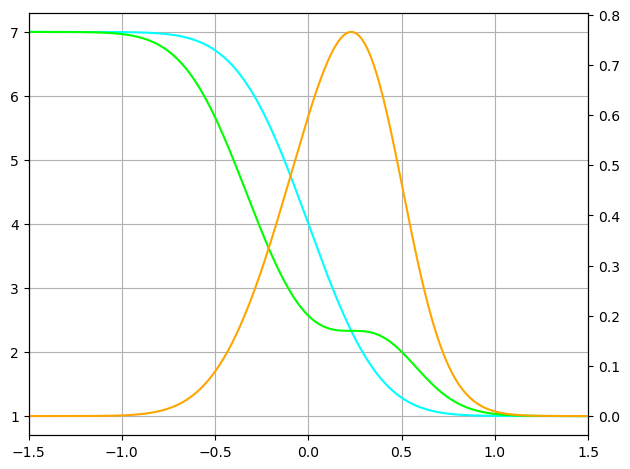

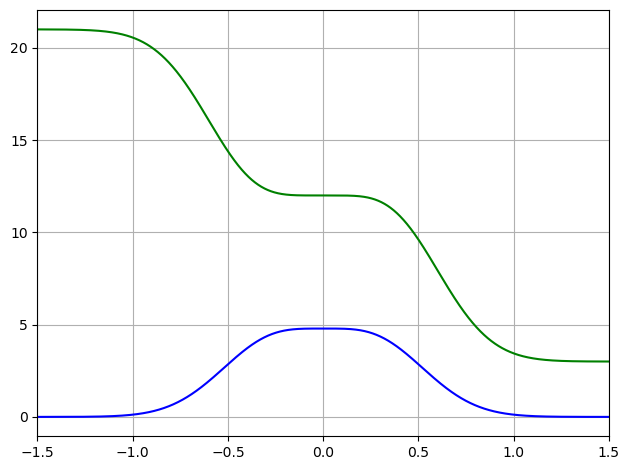

In [5]:
fig, axs = plt.subplots()
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

fig, axs = plt.subplots()
axs.plot(x, u4, label='u4', color='blue')
axs.plot(x, u5, label='u5', color='green')
axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.show()

In [6]:
# Gram Settings
M = 12
closure = "ExtGram"
Kn = 1.0
source_string = "zero_source"#!"relaxation_source"
T_end = 0.3
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

In [7]:
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

polydeg = 2
csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df2 = pd.read_csv(csv_file2)

polydeg = 3
csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df3 = pd.read_csv(csv_file3)

/tmp/ipykernel_1492/930836410.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


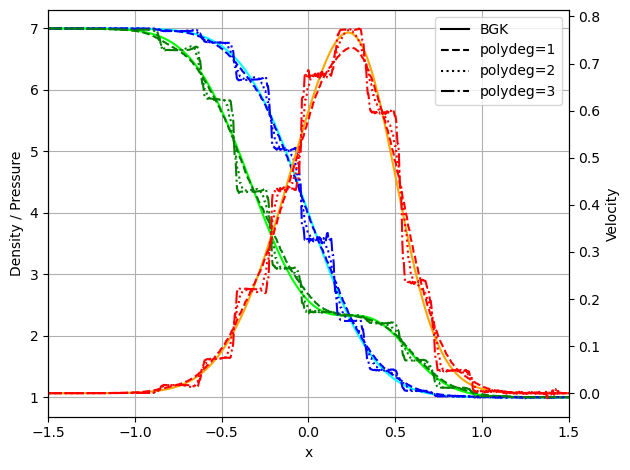

In [8]:
fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM polydeg=2
axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# # HyQMOM polydeg=3
axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='polydeg=1')
axs.plot([], [], color='black', linestyle="dotted", label='polydeg=2')
axs.plot([], [], color='black', linestyle="dashdot", label='polydeg=3')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/BGK_vs_ExtendedGramian_PolydegComparison_Kn1.0.pdf')
fig.show()

/tmp/ipykernel_1492/1945408299.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


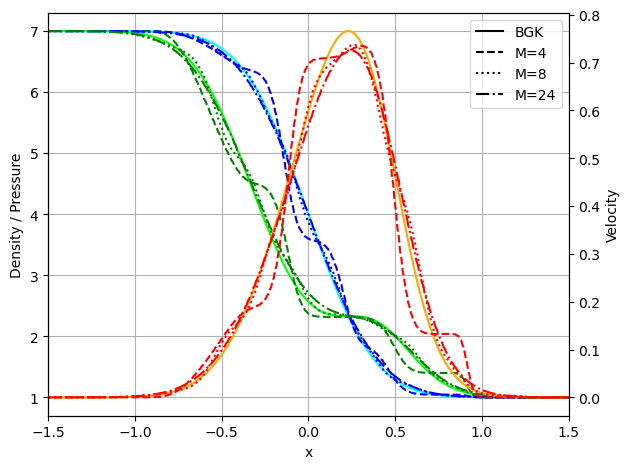

In [9]:
M = 4
polydeg = 1
base_tree_level = 6
csv_file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df = pd.read_csv(csv_file)

M = 8
csv_file2 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df2 = pd.read_csv(csv_file2)

M = 24
csv_file3 = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv"
df3 = pd.read_csv(csv_file3)

fig, axs = plt.subplots()

# BGK
axs.plot(x, rho_T, color='cyan')
axs.plot(x, p_T, color='lime')
ax = axs.twinx()
ax.plot(x, v_T, color='orange')

# HyQMOM - M=4
axs.plot(df['x'], df['rho'], color='blue', linestyle="dashed")
axs.plot(df['x'], df['p'], color='green', linestyle="dashed")
ax.plot(df['x'], df['v'], color='red', linestyle="dashed")

# HyQMOM - M=8
axs.plot(df2['x'], df2['rho'], color='blue', linestyle="dotted")
axs.plot(df2['x'], df2['p'], color='green', linestyle="dotted")
ax.plot(df2['x'], df2['v'], color='red', linestyle="dotted")

# HyQMOM - M=24
axs.plot(df3['x'], df3['rho'], color='blue', linestyle="dashdot")
axs.plot(df3['x'], df3['p'], color='green', linestyle="dashdot")
ax.plot(df3['x'], df3['v'], color='red', linestyle="dashdot")

axs.plot([], [], color='black', label='BGK')
axs.plot([], [], color='black', linestyle="dashed", label='M=4')
axs.plot([], [], color='black', linestyle="dotted", label='M=8')
axs.plot([], [], color='black', linestyle="dashdot", label='M=24')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
ax.set_ylabel('Velocity')
axs.legend(loc='upper right')

axs.set_xlim(-1.5, 1.5)
axs.grid()
fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/BGK_vs_ExtendedGramian_MComparison_Kn1.0.pdf')
fig.show()

## Collisionless

In [10]:
# === Usage Example ===
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

In [11]:
x_BGK = np.linspace(-6, 6, 10_000)
c_BGK = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, x_BGK, c_BGK[:, None], T)
rho_T = np.trapz(f_T, c_BGK, axis=0)
u_0_BGK = np.trapz(c_BGK[:, None]**0 * f_T, c_BGK, axis=0)
v_T = np.trapz(c_BGK[:, None] * f_T, c_BGK, axis=0) / rho_T
u_1_BGK = np.trapz(c_BGK[:, None]**1 * f_T, c_BGK, axis=0)
theta_T = np.trapz((c_BGK[:, None] - v_T)**2 * f_T, c_BGK, axis=0) / rho_T
u_2_BGK = np.trapz(c_BGK[:, None]**2 * f_T, c_BGK, axis=0)
p_T = rho_T * theta_T
u_3_BGK = np.trapz(c_BGK[:, None]**3 * f_T, c_BGK, axis=0)
u_4_BGK = np.trapz(c_BGK[:, None]**4 * f_T, c_BGK, axis=0)

/tmp/ipykernel_1492/1513574794.py:29: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


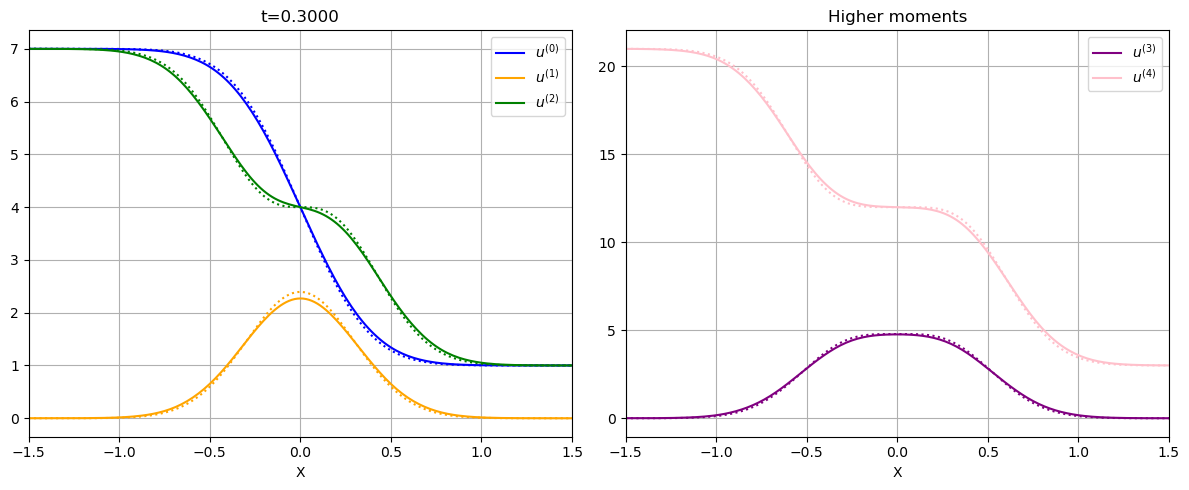

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].plot(x_BGK, u_0_BGK, color='blue', linestyle='dotted')
axes[0].plot(x, u[:,0], label="$u^{(0)}$", color='blue')

axes[0].plot(x_BGK, u_1_BGK, color='orange', linestyle='dotted')
axes[0].plot(x, u[:,1], label="$u^{(1)}$", color='orange')

axes[0].plot(x_BGK, u_2_BGK, color='green', linestyle='dotted')
axes[0].plot(x, u[:,2], label="$u^{(2)}$", color='green')
axes[0].set_title(f"t={t:.4f}")
axes[0].set_xlabel("X")
axes[0].grid()
axes[0].legend()

axes[1].plot(x_BGK, u_3_BGK, color='purple', linestyle='dotted')
axes[1].plot(x, u[:,3], label="$u^{(3)}$", color='purple')

axes[1].plot(x_BGK, u_4_BGK, color='pink', linestyle='dotted')
axes[1].plot(x, u[:,4], label="$u^{(4)}$", color='pink')
axes[1].set_title("Higher moments")
axes[1].set_xlabel("X")
axes[1].grid()
axes[1].legend()

[ax.set_xlim(-1.5, 1.5) for ax in axes]
fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/MomentComparisonM24_ExtGram_BGK.pdf')
fig.show()

In [13]:
def convergence_moments(M):
    filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"
    data = read_solution_file(filename)

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, u, t = sol["x"], sol["u"], sol["t"]

    L2_ = []
    for i in range(M):
        u_BGK = np.trapz(c[:, None]**i * f_T, c_BGK, axis=0)
        u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
        u_BGK_projected = u_BGK_interp1D(x)
        u_ExtGramian = u[:,i]
        L2_.append(
            np.linalg.norm(u_ExtGramian - u_BGK_projected, 2) / np.linalg.norm(u_BGK_projected, 2)
        )
        
    moments_ = np.linspace(0, M-1, M, dtype=int)
    fig, axs = plt.subplots(2)
    axs[0].semilogy(moments_[::2], L2_[::2], '-o', color='blue')
    axs[0].set_xticks(moments_[::2])

    axs[1].semilogy(moments_[1:][::2], L2_[1:][::2], '-o', color='blue')
    axs[1].set_xticks(moments_[1:][::2])

    [ax.grid() for ax in axs]
    [ax.set_xlabel('Moments') for ax in axs]
    [ax.set_ylabel('relative L2 error') for ax in axs]

    fig.tight_layout()
    return fig, axs, moments_, L2_

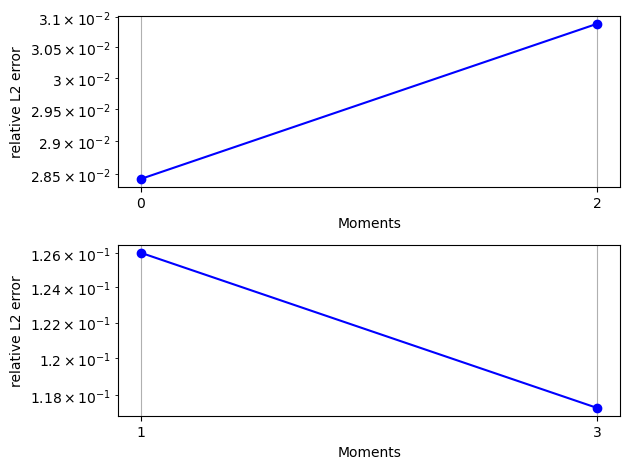

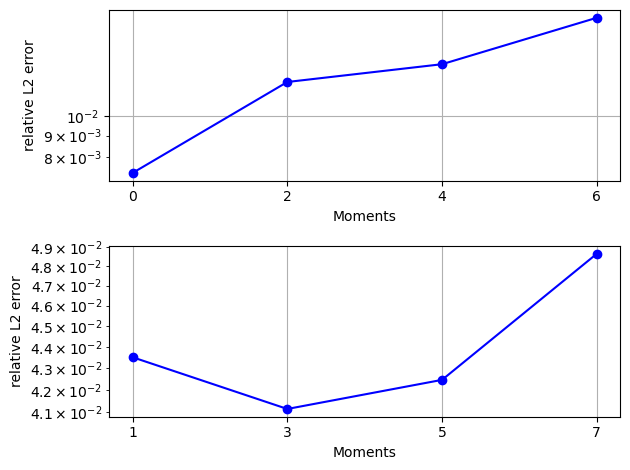

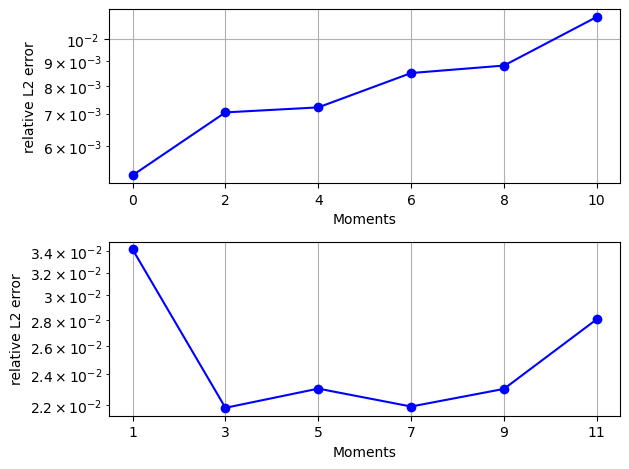

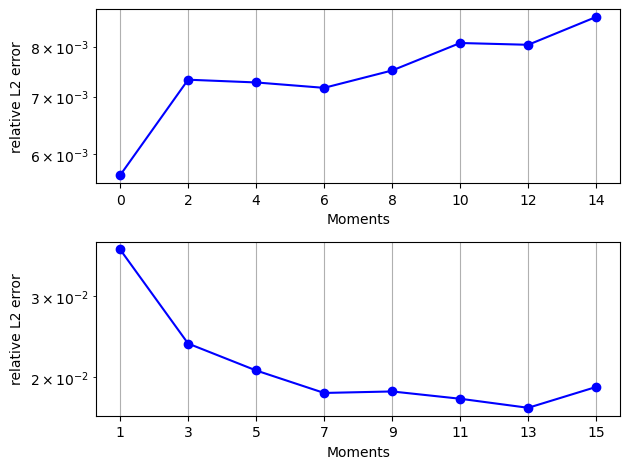

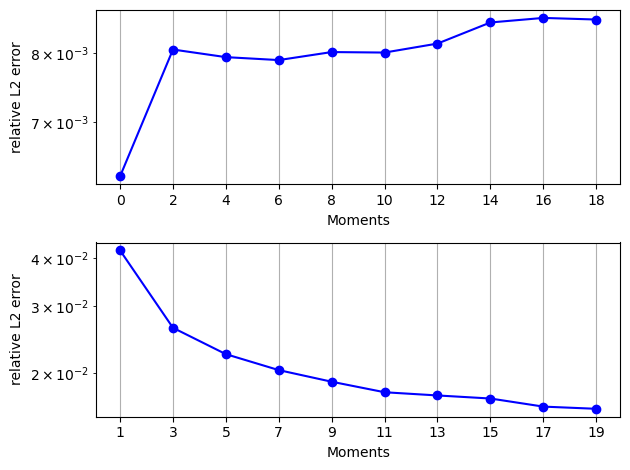

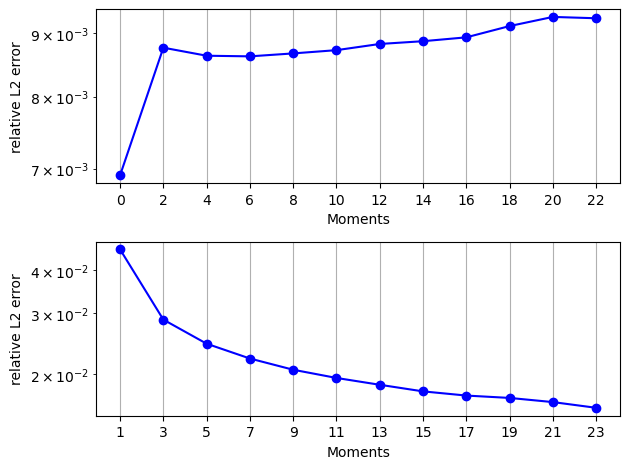

In [14]:
moments, L2 = [], []
M_vector = [4, 8, 12, 16, 20, 24]
for M in M_vector:
    fig, axs, moments_, L2_ = convergence_moments(M)
    # fig.show()

    moments.append(moments_)
    L2.append(L2_)

/tmp/ipykernel_1492/291987008.py:20: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


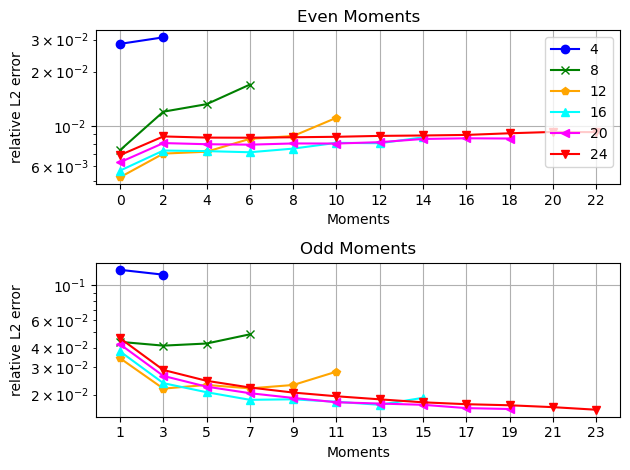

In [15]:
colors = ['blue', 'green', 'orange', 'cyan', 'magenta', 'red']
marker = ['-o', '-x', '-p', '-^', '-<', '-v']

fig, axs = plt.subplots(2)
[axs[0].semilogy(moments[i][::2], L2[i][::2], marker[i], color=colors[i], label=M) for i, M in enumerate(M_vector)]
axs[0].set_xticks(moments[-1][::2])
axs[0].legend()
axs[0].set_title('Even Moments')

[axs[1].semilogy(moments[i][1:][::2], L2[i][1:][::2], marker[i], color=colors[i]) for i, M in enumerate(M_vector)]
axs[1].set_xticks(moments[-1][1:][::2])
axs[1].set_title('Odd Moments')

[ax.grid() for ax in axs]
[ax.set_xlabel('Moments') for ax in axs]
[ax.set_ylabel('relative L2 error') for ax in axs]

fig.tight_layout()
fig.savefig("../out/Figures/Riemann1D/MomentConvergenceToBGK.pdf")
fig.show()

## Collisions

In [16]:
source_string = 'relaxation_source'
Kn = 1.0
base_tree_level = 6
M_vec = [4, 8, 12, 16, 20, 24]

In [18]:
# === Usage Example ===
filename = f"../out/Riemann1D/Moments/gram_solution_M{M_vec[-1]}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"   # <-- replace with your file
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

In [22]:
file_BGK = 'bgk_solution_N200_Kn1.0_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1.tsv'
data_BGK = read_solution_file_bgk(f"../out/Riemann1D/BGK/{file_BGK}")

# Build time → timestep mapping
times = np.array([data_BGK[ts]["t"] for ts in sorted(data_BGK.keys())])
timesteps = np.array(sorted(data_BGK.keys()))

sol = interpolate_solution_bgk(data_BGK, time_query, times, timesteps)
x_BGK, f_BGK, t_BGK = sol["x"], sol["f"], sol["t"]

In [23]:
c_l, c_u = -6.0, 6.0

In [24]:
c_BGK = np.linspace(c_l, c_u, f_BGK.shape[1])
u_0_BGK = np.trapz(c_BGK[:, None]**0 * f_BGK.T, c_BGK, axis=0)
u_1_BGK = np.trapz(c_BGK[:, None]**1 * f_BGK.T, c_BGK, axis=0)
u_2_BGK = np.trapz(c_BGK[:, None]**2 * f_BGK.T, c_BGK, axis=0)
u_3_BGK = np.trapz(c_BGK[:, None]**3 * f_BGK.T, c_BGK, axis=0)
u_4_BGK = np.trapz(c_BGK[:, None]**4 * f_BGK.T, c_BGK, axis=0)

/tmp/ipykernel_1492/4038494791.py:29: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


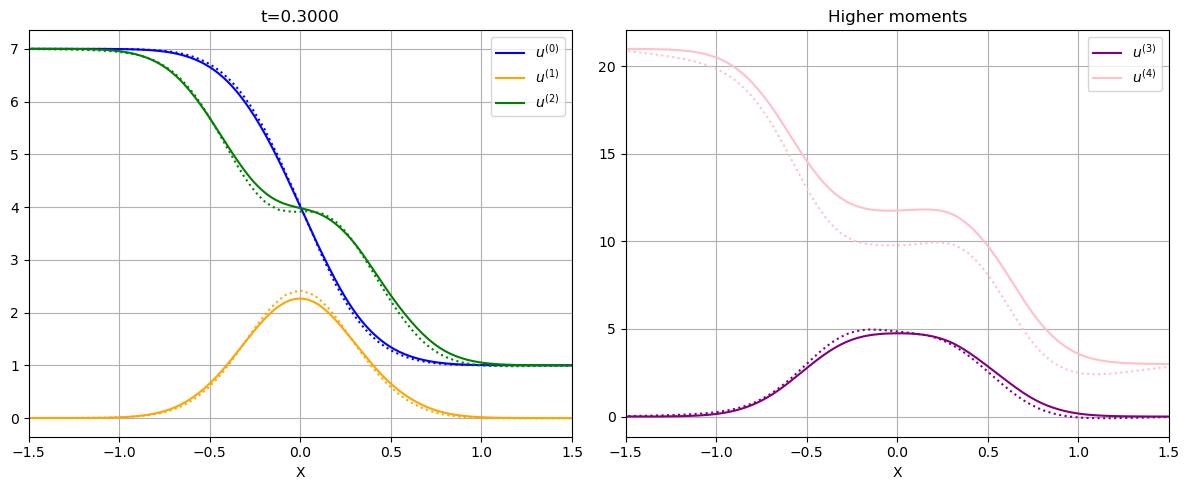

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].plot(x_BGK, u_0_BGK, color='blue', linestyle='dotted')
axes[0].plot(x, u[:,0], label="$u^{(0)}$", color='blue')

axes[0].plot(x_BGK, u_1_BGK, color='orange', linestyle='dotted')
axes[0].plot(x, u[:,1], label="$u^{(1)}$", color='orange')

axes[0].plot(x_BGK, u_2_BGK, color='green', linestyle='dotted')
axes[0].plot(x, u[:,2], label="$u^{(2)}$", color='green')
axes[0].set_title(f"t={t:.4f}")
axes[0].set_xlabel("X")
axes[0].grid()
axes[0].legend()

axes[1].plot(x_BGK, u_3_BGK, color='purple', linestyle='dotted')
axes[1].plot(x, u[:,3], label="$u^{(3)}$", color='purple')

axes[1].plot(x_BGK, u_4_BGK, color='pink', linestyle='dotted')
axes[1].plot(x, u[:,4], label="$u^{(4)}$", color='pink')
axes[1].set_title("Higher moments")
axes[1].set_xlabel("X")
axes[1].grid()
axes[1].legend()

[ax.set_xlim(-1.5, 1.5) for ax in axes]
fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/MomentComparisonM24_ExtGram_BGK.pdf')
fig.show()

In [28]:
def convergence_moments(M, closure="ExtGram", polydeg=1, base_tree_level=6):
    filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"   # <-- replace with your file
    data = read_solution_file(filename)

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, u, t = sol["x"], sol["u"], sol["t"]

    file_BGK = 'bgk_solution_N200_Kn1.0_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1.tsv'
    data_BGK = read_solution_file_bgk(f"../out/Riemann1D/BGK/{file_BGK}")

    # Build time → timestep mapping
    times = np.array([data_BGK[ts]["t"] for ts in sorted(data_BGK.keys())])
    timesteps = np.array(sorted(data_BGK.keys()))

    sol = interpolate_solution_bgk(data_BGK, time_query, times, timesteps)
    x_BGK, f_BGK, t_BGK = sol["x"], sol["f"], sol["t"]
    
    c_l, c_u = -6.0, 6.0

    c_BGK = np.linspace(c_l, c_u, f_BGK.shape[1])

    L2_ = []
    for i in range(M):
        u_BGK = np.trapz(c_BGK[:, None]**i * f_BGK.T, c_BGK, axis=0)
        u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
        u_BGK_projected = u_BGK_interp1D(x)
        u_ExtGramian = u[:,i]
        L2_.append(
            np.linalg.norm(u_ExtGramian - u_BGK_projected, 2) / np.linalg.norm(u_BGK_projected, 2)
        )
        
    moments_ = np.linspace(0, M-1, M, dtype=int)
    fig, axs = plt.subplots(2)
    axs[0].semilogy(moments_[::2], L2_[::2], '-o', color='blue')
    axs[0].set_xticks(moments_[::2])

    axs[1].semilogy(moments_[1:][::2], L2_[1:][::2], '-o', color='blue')
    axs[1].set_xticks(moments_[1:][::2])

    [ax.grid() for ax in axs]
    [ax.set_xlabel('Moments') for ax in axs]
    [ax.set_ylabel('relative L2 error') for ax in axs]

    fig.tight_layout()
    return fig, axs, moments_, L2_

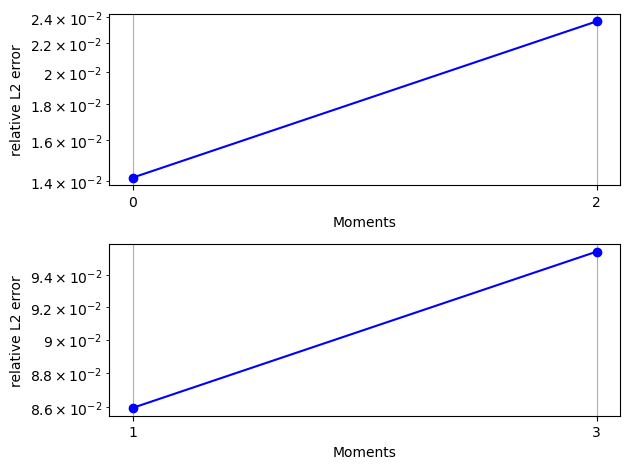

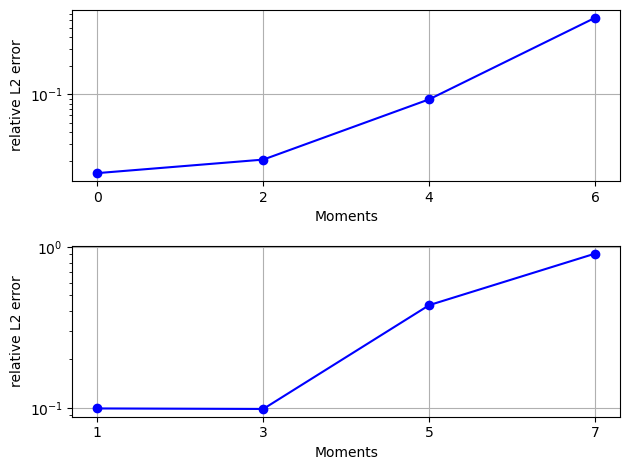

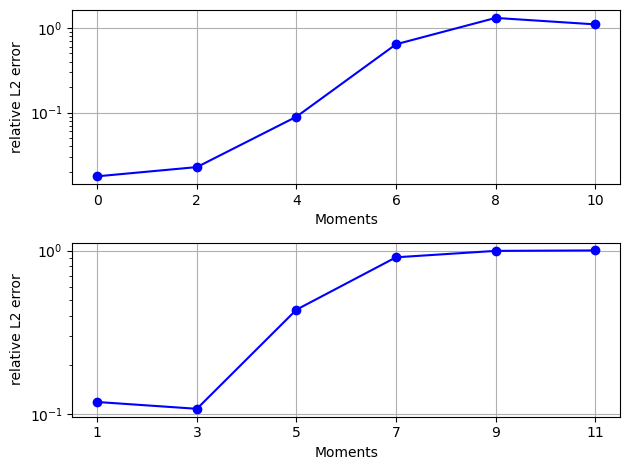

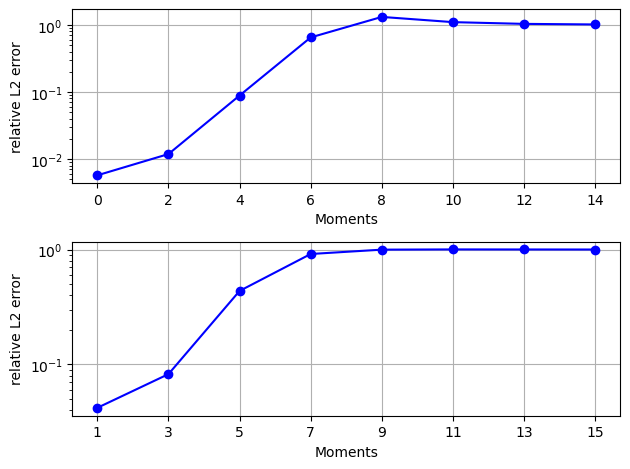

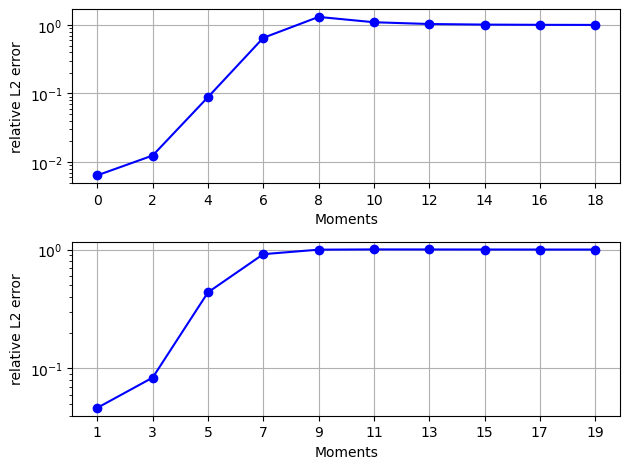

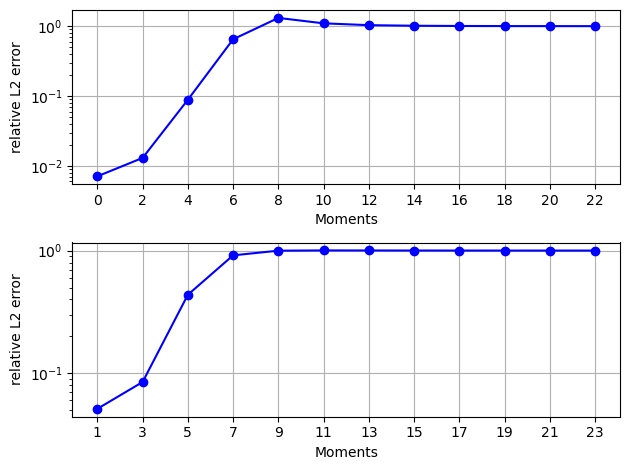

In [29]:
moments, L2 = [], []
M_vector = [4, 8, 12, 16, 20, 24]
for M in M_vector:
    fig, axs, moments_, L2_ = convergence_moments(M)
    # fig.show()

    moments.append(moments_)
    L2.append(L2_)

/tmp/ipykernel_1492/4170235574.py:20: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


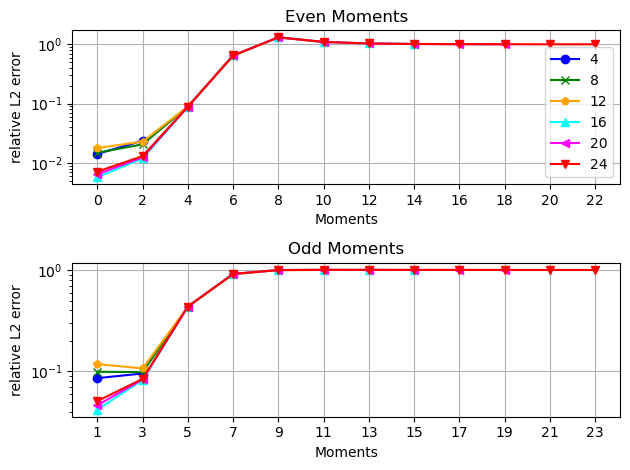

In [30]:
colors = ['blue', 'green', 'orange', 'cyan', 'magenta', 'red']
marker = ['-o', '-x', '-p', '-^', '-<', '-v']

fig, axs = plt.subplots(2)
[axs[0].semilogy(moments[i][::2], L2[i][::2], marker[i], color=colors[i], label=M) for i, M in enumerate(M_vector)]
axs[0].set_xticks(moments[-1][::2])
axs[0].legend()
axs[0].set_title('Even Moments')

[axs[1].semilogy(moments[i][1:][::2], L2[i][1:][::2], marker[i], color=colors[i]) for i, M in enumerate(M_vector)]
axs[1].set_xticks(moments[-1][1:][::2])
axs[1].set_title('Odd Moments')

[ax.grid() for ax in axs]
[ax.set_xlabel('Moments') for ax in axs]
[ax.set_ylabel('relative L2 error') for ax in axs]

fig.tight_layout()
fig.savefig("../out/Figures/Riemann1D/MomentConvergenceToBGK_Kn1.0.pdf")
fig.show()

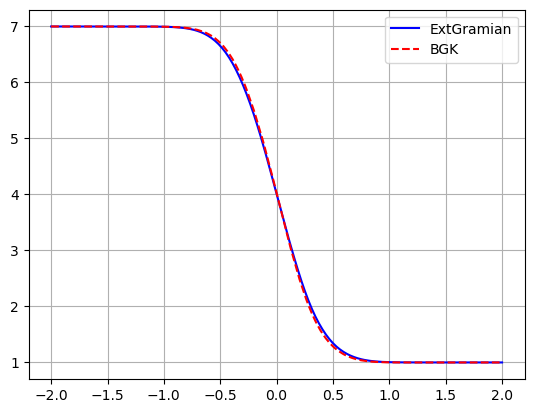

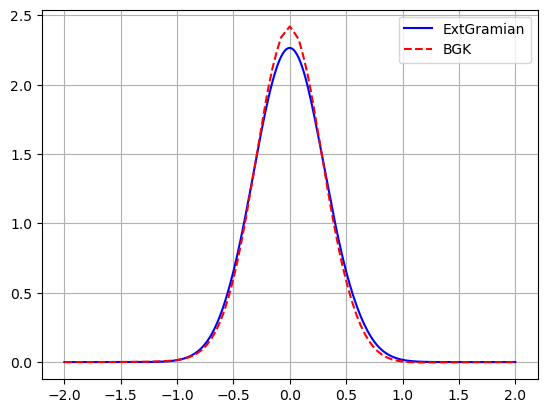

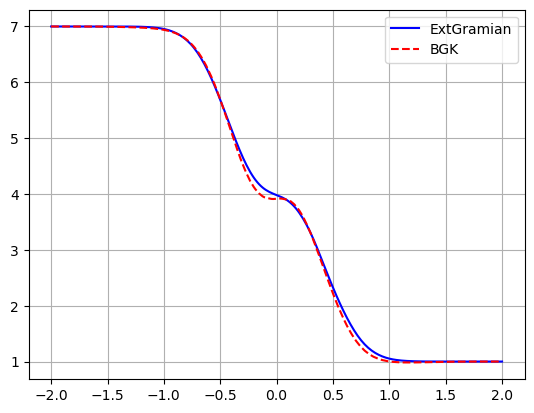

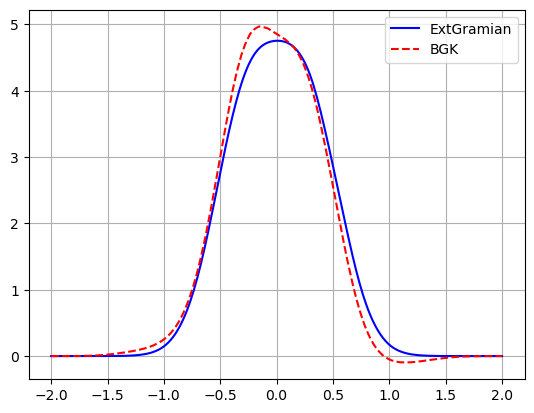

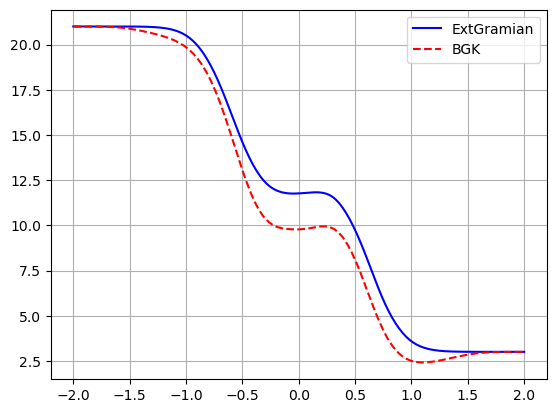

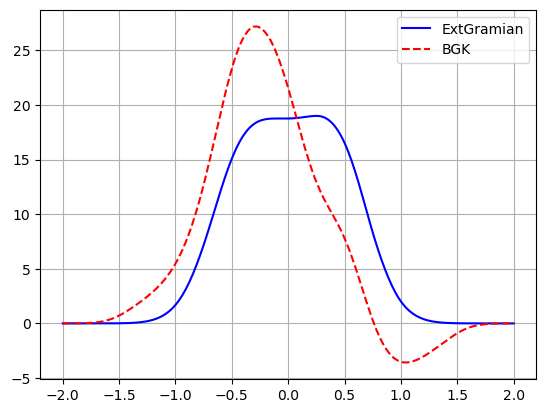

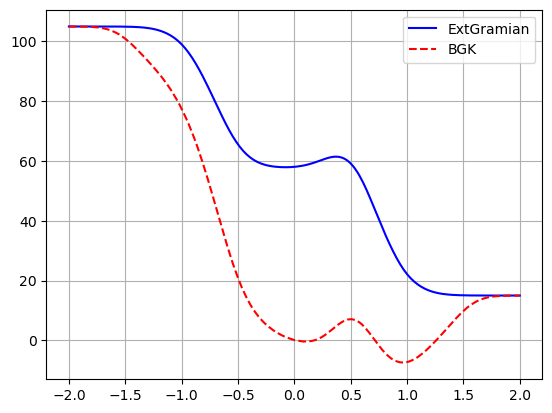

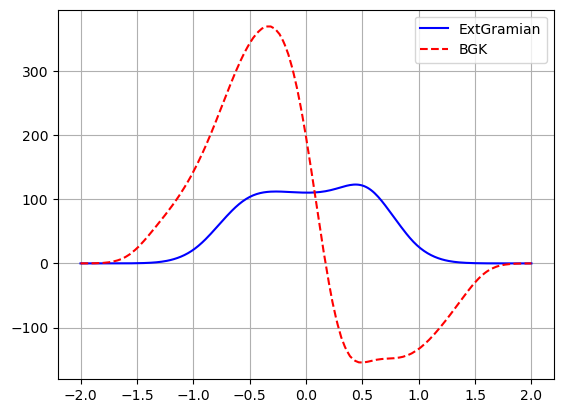

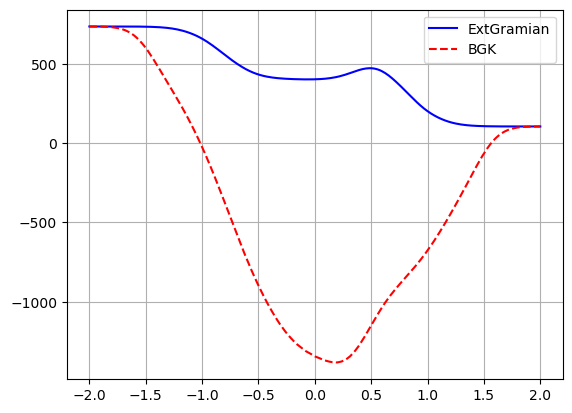

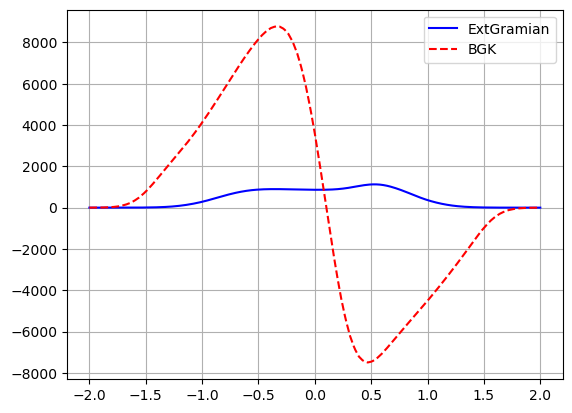

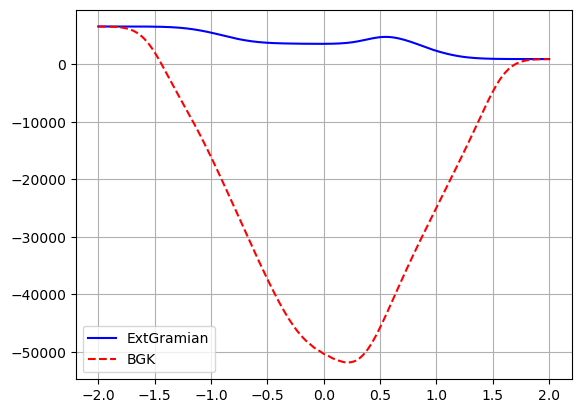

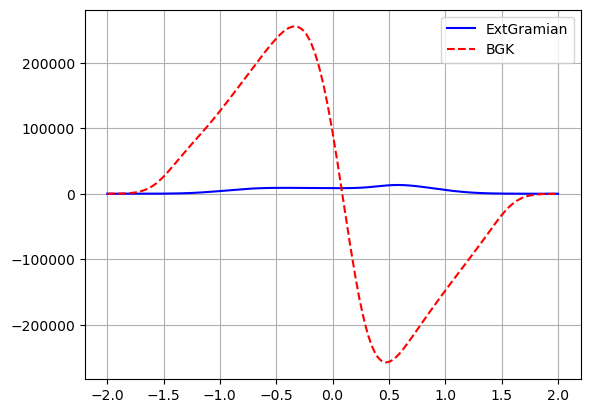

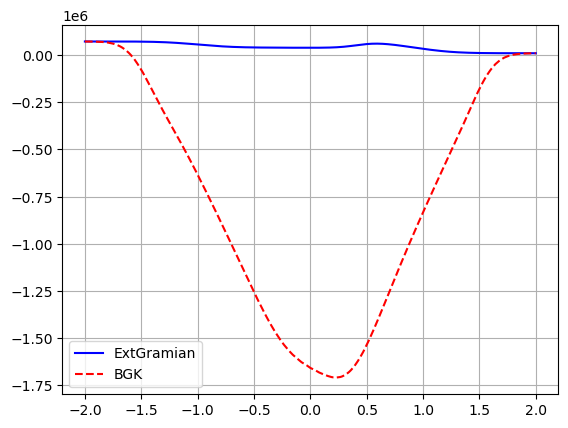

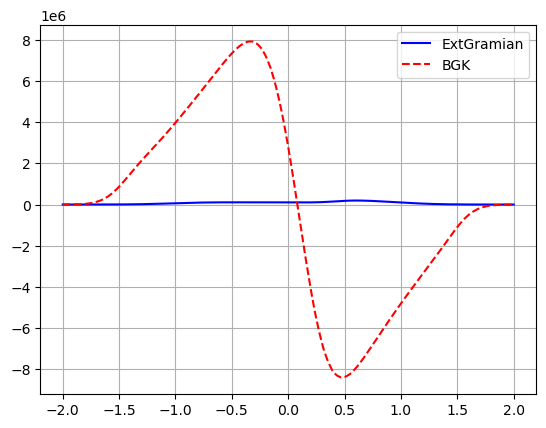

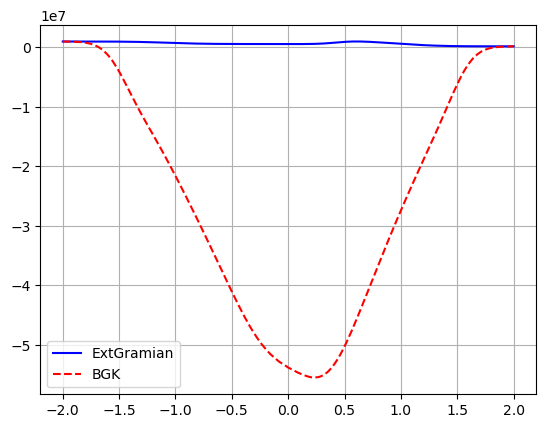

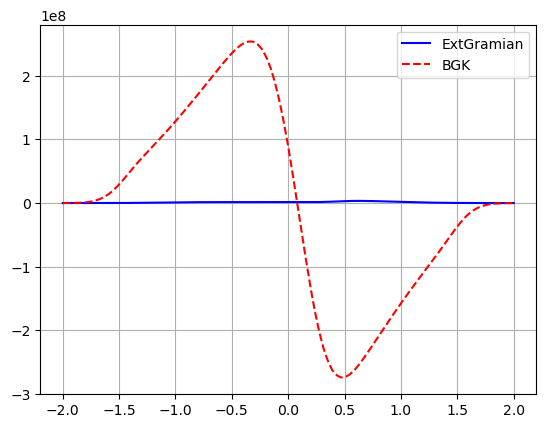

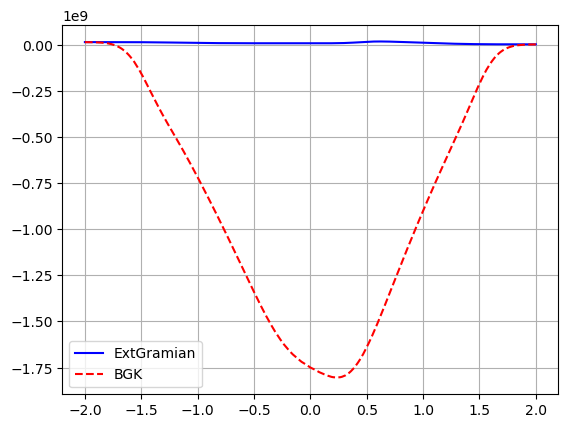

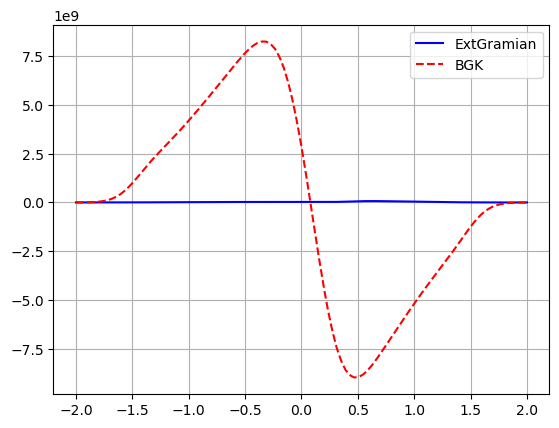

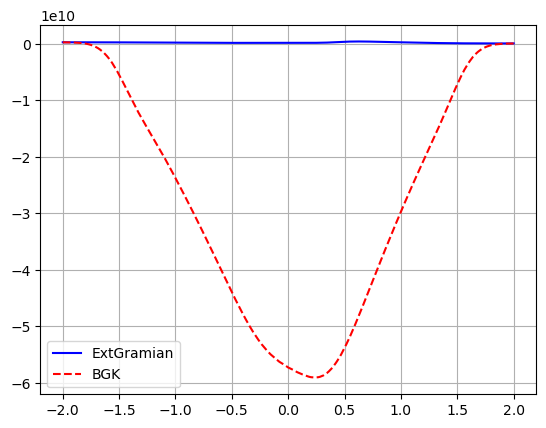

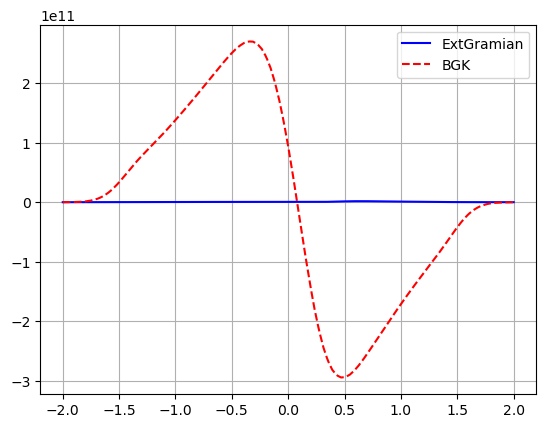

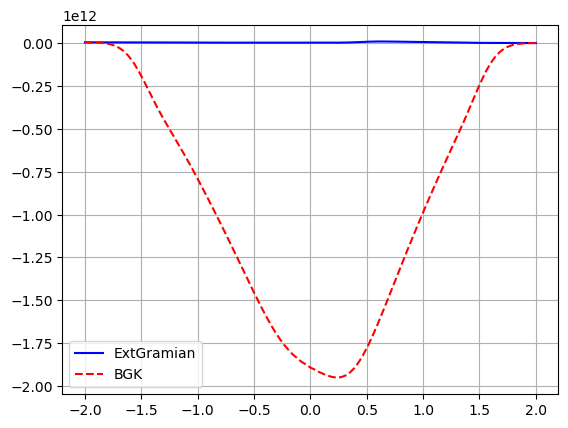

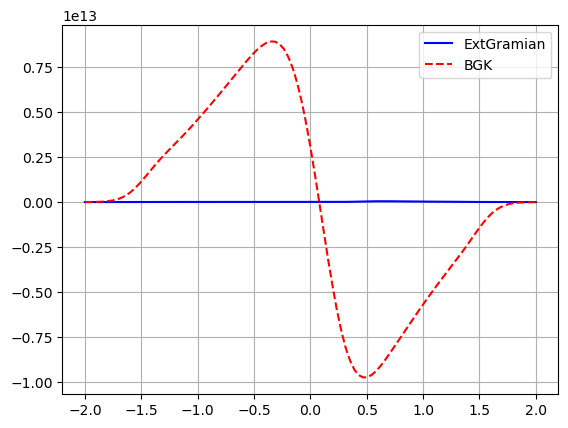

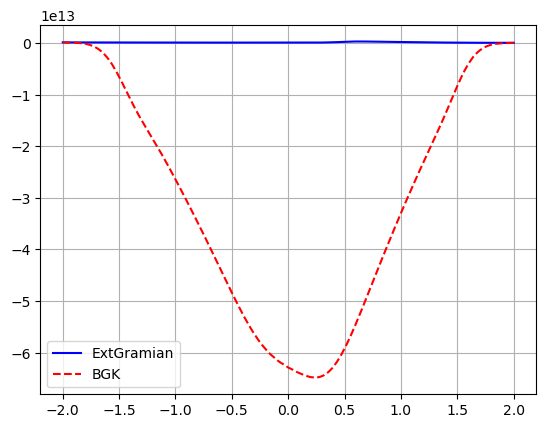

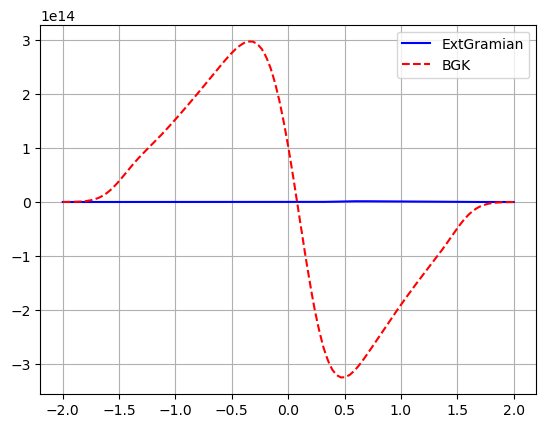

In [32]:
M = M_vec[-1]
base_tree_level = 6
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"   # <-- replace with your file
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]


file_BGK = 'bgk_solution_N200_Kn1.0_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1.tsv'
data_BGK = read_solution_file_bgk(f"../out/Riemann1D/BGK/{file_BGK}")

# Build time → timestep mapping
times = np.array([data_BGK[ts]["t"] for ts in sorted(data_BGK.keys())])
timesteps = np.array(sorted(data_BGK.keys()))

sol = interpolate_solution_bgk(data_BGK, time_query, times, timesteps)
x_BGK, f_BGK, t_BGK = sol["x"], sol["f"], sol["t"]

c_l, c_u = -6.0, 6.0

c_BGK = np.linspace(c_l, c_u, f_BGK.shape[1])

for i in range(M):
    u_BGK = np.trapz(c_BGK[:, None]**i * f_BGK.T, c_BGK, axis=0)
    u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
    u_BGK_projected = u_BGK_interp1D(x)
    u_ExtGramian = u[:,i]
    plt.figure()
    plt.plot(x, u_ExtGramian, label='ExtGramian', color='blue', linestyle='solid')
    plt.plot(x, u_BGK_projected, label='BGK', color='red', linestyle='dashed')
    plt.grid()
    plt.legend()
    plt.show()